In [86]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import gpytorch

from dataset import DiffusionDataset, get_dataloader, sin_1d
from diffusion import Diffusion
from gp_models import ApproximateGP

# Sanity check

In [87]:
dataset = DiffusionDataset(dataset_name='sin_1d', n_samples=3000, seed=42, x_normalise=True, y_normalise=True)
train_loader, test_loader, val_loader = get_dataloader(dataset, batch_size=32, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)
batch = next(iter(train_loader))
batch['X'][:5]

tensor([[-1.1671],
        [ 1.2422],
        [-1.2243],
        [ 1.5483],
        [ 1.3323]])

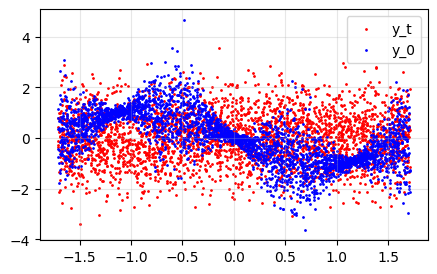

In [24]:
plt.figure(figsize=(5, 3))
plt.grid(alpha=0.3)
y_0 = dataset.y
x = dataset.X
t = 1000
diffusion = Diffusion(T=t)

noise = torch.randn_like(y_0)
y_t = diffusion.q_sample(y_0, 1000, noise)

plt.scatter(x[:], y_t, s=1, c='r')
plt.scatter(x[:], y_0, s=1, c='b')
plt.legend(['y_t', 'y_0'])
plt.show()

# Inducing points GP

In [88]:
def train_gp(diffusion, train_loader, val_loader, num_epochs, lr, mean_type, matern_nu, update_epoch=False, device=None, num_inducing_points=300, loss_type="mse", seed=42):
    # Initialisations
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    total_dim = next(iter(train_loader))['X'].shape[1] + 2
    T = diffusion.T
    model = ApproximateGP(num_inducing_points, total_dim, mean_type, matern_nu, seed).to(device)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if loss_type == "mse":
        loss_fn = torch.nn.MSELoss()
    elif loss_type == "elbo":
        loss_fn = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_loader.dataset))
    else:
        raise ValueError(f"Loss type {loss_type} not supported")
    train_losses = []
    val_losses = []
    
    # Training loop
    with tqdm(total=num_epochs) as pbar:
        for epoch in range(num_epochs):
            # Training phase
            model.train()
            likelihood.train()
            train_loss = 0
            train_num_batches = 0
            for batch in train_loader:
                # Initialistions
                x = batch['X'].to(device)
                y_0 = batch['y'].to(device)
                t = torch.randint(1, T, (y_0.shape), device=device)
                noise = torch.randn_like(y_0, device=device)
                y_t = diffusion.q_sample(y_0, t, noise)
                assert x.dim() == y_0.dim() == t.dim() == y_t.dim(), "x, y_0, t, y_t must have the same dimension" # check x, y_0, t have the same dimensions
                t = t / T # normalise time step
                z = torch.cat([x, t, y_t], dim=1) # concatenate x, t, y_t as input to model

                # Forward pass
                score = model(z)
                if loss_type == "mse":
                    loss = loss_fn(score.mean, noise[:,0])
                elif loss_type == "elbo":
                    loss = -loss_fn(score, noise[:,0])
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
                train_num_batches += 1
            train_losses.append(train_loss / train_num_batches)

            # Validation phase
            model.eval()
            likelihood.eval()
            val_loss = 0
            val_num_batches = 0
            for batch in val_loader:
                # Initialistions
                x = batch['X'].to(device)
                y_0 = batch['y'].to(device)
                t = torch.randint(1, T, (y_0.shape), device=device)
                noise = torch.randn_like(y_0, device=device)
                y_t = diffusion.q_sample(y_0, t, noise)
                assert x.dim() == y_0.dim() == t.dim() == y_t.dim(), "x, y_0, t, y_t must have the same dimension" # check x, y_0, t have the same dimensions
                t = t / T # normalise time step
                z = torch.cat([x, t, y_t], dim=1) # concatenate x, t, y_t as input to model

                # Forward pass
                score = model(z)
                if loss_type == "mse":
                    loss = loss_fn(score.mean, noise[:,0])
                elif loss_type == "elbo":
                    loss = -loss_fn(score, noise[:,0])
                val_loss += loss.item()
                val_num_batches += 1
            val_losses.append(val_loss / val_num_batches)
            if update_epoch:
                if epoch % 10 == 0:
                    print(f"Epoch {epoch}, Train loss: {train_losses[-1]}, Val loss: {val_losses[-1]}")
            pbar.update(1)
    return model, likelihood, train_losses, val_losses

In [89]:
def sample_dgp(model, likelihood, T, X, y_t, diffusion, clamp=False, clamp_mag = 3.0):
    model.eval()
    likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for t in range(T-1, -1, -1): # reverse time steps
            t_tensor = torch.ones_like(y_t, dtype=torch.float32) * (t+1) / T # normalise time step
            assert X.dtype == y_t.dtype == t_tensor.dtype, "All inputs must be float32"
            z = torch.cat([X, t_tensor, y_t], dim=1)
            score = model(z).mean.reshape(-1, 1)
            assert score.shape == y_t.shape, "score and y_t must have the same shape"
            y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score) # update y_t
            y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t]) # add noise
            # Clamping for stability
            if clamp: 
                y_t = torch.clamp(y_t, min=-clamp_mag, max=clamp_mag)
            
    return y_t

In [99]:
num_epochs = 100
lr = 0.01
num_inducing_points = 1000
loss_type = "mse"
T = 1000
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results = {}
dataset = DiffusionDataset(dataset_name='elevators', n_samples=3000, seed=42, x_normalise=True, y_normalise=True)
train_loader, test_loader, val_loader = get_dataloader(dataset, batch_size=32, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)
diffusion = Diffusion(T=T)
x_scalar, y_scalar = dataset.get_scalers()

## Parameter search

In [38]:
## Synthetic DGP grid search
# Parameters
mean_types = ['linear', 'constant', 'zero']
matern_nus = [
    [0.5, 0.5, 0.5], [0.5, 0.5, 1.5], [0.5, 0.5, 2.5],
    [0.5, 1.5, 0.5], [0.5, 1.5, 1.5], [0.5, 1.5, 2.5],
    [0.5, 2.5, 0.5], [0.5, 2.5, 1.5], [0.5, 2.5, 2.5],
    [1.5, 0.5, 0.5], [1.5, 0.5, 1.5], [1.5, 0.5, 2.5],
    [1.5, 1.5, 0.5], [1.5, 1.5, 1.5], [1.5, 1.5, 2.5],
    [1.5, 2.5, 0.5], [1.5, 2.5, 1.5], [1.5, 2.5, 2.5],
    [2.5, 0.5, 0.5], [2.5, 0.5, 1.5], [2.5, 0.5, 2.5],
    [2.5, 1.5, 0.5], [2.5, 1.5, 1.5], [2.5, 1.5, 2.5],
    [2.5, 2.5, 0.5], [2.5, 2.5, 1.5], [2.5, 2.5, 2.5]
]

for mean_type in mean_types:
    for matern_nu in matern_nus:
        model, likelihood, train_losses, val_losses = train_gp(diffusion=diffusion, update_epoch=False, train_loader=train_loader, val_loader=val_loader, num_epochs=num_epochs, lr=lr, mean_type=mean_type, matern_nu=matern_nu, loss_type=loss_type, num_inducing_points=num_inducing_points, device=device, seed=42)
        locations = []
        predictions = []
        true_values = []
        with tqdm(total=len(test_loader)) as pbar:
            for batch in test_loader:
                # Initialisations
                X = batch['X'].to(device)
                y_0 = batch['y'].to(device)
                y_t = torch.randn_like(y_0, device=device)
                
                # Sampling
                sample = sample_dgp(model, likelihood, T, X, y_t, diffusion, clamp=True)
                predictions.append(sample.detach().cpu().numpy())
                true_values.append(y_0.detach().cpu().numpy())
                locations.append(X.detach().cpu().numpy())
                pbar.update(1)
        # Post-processing
        locations = np.concatenate(locations, axis=0)
        predictions = np.concatenate(predictions, axis=0)
        true_values = np.concatenate(true_values, axis=0)
        rmse = np.sqrt(np.mean((predictions - true_values)**2))
        results[mean_type, str(matern_nu)] = rmse
        print(f"RMSE on test set for {mean_type} and {matern_nu} matern nu: {rmse}")

100%|██████████| 10/10 [00:08<00:00,  1.24it/s]


RMSE on test set for linear and [0.5, 0.5, 0.5] matern nu: 0.8597224950790405


100%|██████████| 10/10 [00:09<00:00,  1.05it/s]


RMSE on test set for linear and [0.5, 0.5, 1.5] matern nu: 0.8626432418823242


100%|██████████| 10/10 [00:08<00:00,  1.22it/s]


...

RMSE on test set for zero and [2.5, 2.5, 0.5] matern nu: 0.8728802800178528


100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


RMSE on test set for zero and [2.5, 2.5, 1.5] matern nu: 0.9100991487503052


100%|██████████| 10/10 [00:08<00:00,  1.20it/s]

RMSE on test set for zero and [2.5, 2.5, 2.5] matern nu: 0.8837719559669495


## Model performance

In [102]:
## Synthetic DGP grid search
# Parameters
mean_types = ['constant']
matern_nus = [[1.5, 1.5, 1.5]]

for mean_type in mean_types:
    for matern_nu in matern_nus:
        model, likelihood, train_losses, val_losses = train_gp(diffusion=diffusion, update_epoch=False, train_loader=train_loader, val_loader=val_loader, num_epochs=num_epochs, lr=lr, mean_type=mean_type, matern_nu=matern_nu, loss_type=loss_type, num_inducing_points=num_inducing_points, device=device, seed=42)
        locations = []
        predictions = []
        true_values = []
        with tqdm(total=len(test_loader)) as pbar:
            for batch in test_loader:
                # Initialisations
                X = batch['X'].to(device)
                y_0 = batch['y'].to(device)
                y_t = torch.randn_like(y_0, device=device)
                
                # Sampling
                sample = sample_dgp(model, likelihood, T, X, y_t, diffusion, clamp=True, clamp_mag=5)
                predictions.append(sample.detach().cpu().numpy())
                true_values.append(y_0.detach().cpu().numpy())
                locations.append(X.detach().cpu().numpy())
                pbar.update(1)
        # Post-processing
        locations = np.concatenate(locations, axis=0)
        predictions = np.concatenate(predictions, axis=0)
        true_values = np.concatenate(true_values, axis=0)
        rmse = np.sqrt(np.mean((predictions - true_values)**2))
        results[mean_type, str(matern_nu)] = rmse
        print(f"RMSE on test set for {mean_type} and {matern_nu} matern nu: {rmse}")

100%|██████████| 52/52 [01:06<00:00,  1.27s/it]

RMSE on test set for constant and [1.5, 1.5, 1.5] matern nu: 0.4529874324798584


In [103]:
from sklearn.datasets import fetch_openml
elevators = fetch_openml('elevators', as_frame=True)
elevators.data.head()

/opt/anaconda3/envs/dgp/lib/python3.11/site-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name elevators exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=216
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=846

  warn(warning_msg)


,climbRate,Sgz,p,q,curRoll,absRoll,diffClb,diffRollRate,diffDiffClb,SaTime1,SaTime2,SaTime3,SaTime4,diffSaTime1,diffSaTime2,diffSaTime3,diffSaTime4,Sa
0,118,-55,-0.28,-0.08,-0.2,-11,11,0.005,-0.2,-0.0010,-0.0010,-0.0010,-0.0010,0.0000,0.0,0.0,0.0,-0.0010
1,390,-45,-0.06,-0.07,-0.6,-12,11,0.010,-0.2,-0.0008,-0.0008,-0.0008,-0.0008,0.0000,0.0,0.0,0.0,-0.0008
2,68,6,0.11,0.15,0.6,-10,-9,-0.003,-0.2,-0.0011,-0.0010,-0.0010,-0.0010,-0.0002,0.0,0.0,0.0,-0.0010
3,-358,-12,-0.20,0.13,-0.3,-11,-7,0.001,-0.1,-0.0010,-0.0010,-0.0010,-0.0010,0.0000,0.0,0.0,0.0,-0.0010
4,-411,-19,-0.18,0.02,-0.5,-11,-3,0.002,1.2,-0.0010,-0.0010,-0.0010,-0.0010,0.0000,0.0,0.0,0.0,-0.0010


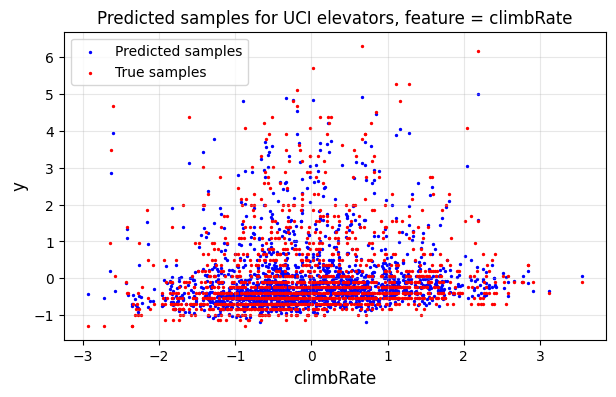

In [104]:
plt.figure(figsize=(7, 4))
plt.grid(alpha=0.3)
feature_index = 0
plt.scatter(locations[:,feature_index], predictions, s=2, c='b', label='Predicted samples')
plt.scatter(locations[:,feature_index], true_values, s=2, c='r', label='True samples')
plt.xlabel(f'{elevators.feature_names[feature_index]}', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title(f'Predicted samples for UCI elevators, feature = {elevators.feature_names[feature_index]}', fontsize=12)
plt.legend()
plt.show()

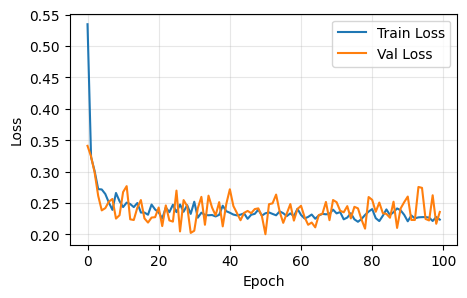

In [16]:

plt.figure(figsize=(5, 3))
plt.grid(alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.show()

In [96]:
# Initialisations
x_scalar, y_scalar = dataset.get_scalers()
x_locations = torch.linspace(0, 1, 200, dtype=torch.float32)
x_locations = x_locations.reshape(-1, 1)
x_locations = torch.tensor(x_scalar.transform(x_locations), device=device).to(torch.float32)
y_t = torch.randn_like(torch.zeros(x_locations.shape[0], 1), device=device, dtype=torch.float32)
num_samples = 50
samples = torch.empty(x_locations.shape[0], num_samples, device=device, dtype=torch.float32)

with tqdm(total=num_samples) as pbar:
    for i in range(num_samples):
        samples[:, i] = sample_dgp(model, likelihood, T, x_locations, y_t, diffusion, clamp=True)[:, 0]
        pbar.update(1)

samples = y_scalar.inverse_transform(samples)
x_locations = x_scalar.inverse_transform(x_locations)

 24%|██▍       | 12/50 [00:45<02:23,  3.78s/it]


KeyboardInterrupt: 

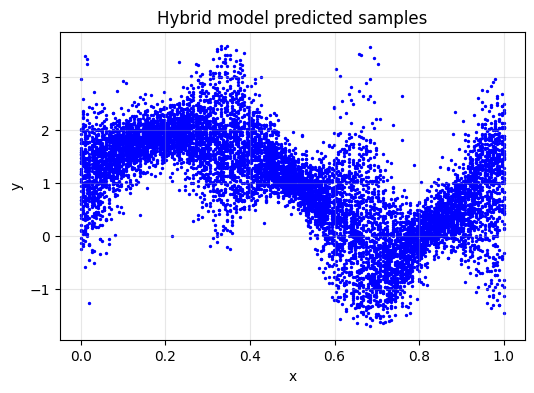

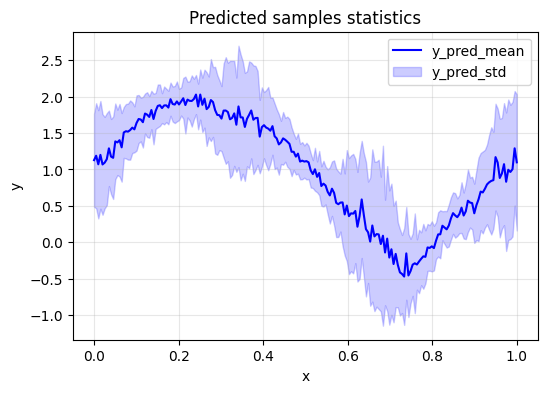

In [ ]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Hybrid model predicted samples')
for i in range(samples.shape[1]):
    plt.scatter(x_locations, samples[:, i], s=2, c='b', label='y_t')

plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted samples statistics')
y_pred_mean = np.mean(samples, axis=1)
# get the variance of the predicted samples
y_pred_std = np.std(samples, axis=1)
# plot the mean and std of the predicted samples
plt.plot(x_locations, y_pred_mean, label='y_pred_mean', c='b')
plt.fill_between(x_locations[:,0], y_pred_mean - y_pred_std, y_pred_mean + y_pred_std, alpha=0.2, label='y_pred_std', color='b')
plt.legend()

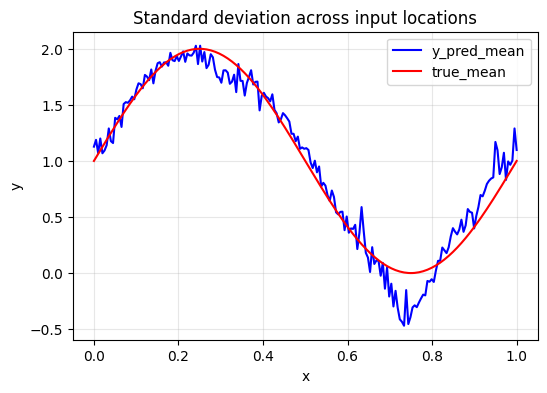

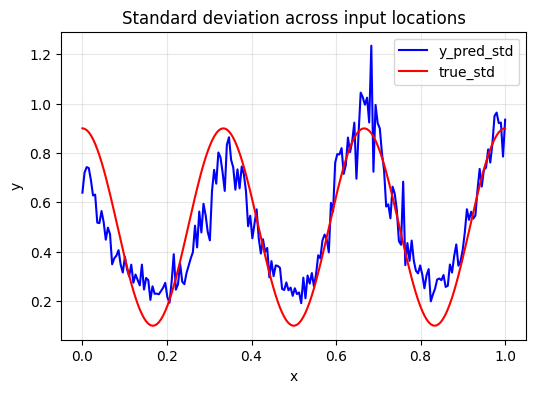

In [50]:
# plot the standard deviation across input locations
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard deviation across input locations')
plt.plot(x_locations, y_pred_mean, label='y_pred_mean', c='b')
# plot the true mean
plt.plot(x_locations, 1 + np.sin(2 * np.pi * x_locations), label='true_mean', c='r')
plt.legend(loc='upper right')

# plot the standard deviation across input locations
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard deviation across input locations')
plt.plot(x_locations, y_pred_std, label='y_pred_std', c='b')
# plot the true standard deviation
plt.plot(x_locations, 0.5 + 0.4 * np.cos(6 * np.pi * x_locations), label='true_std', c='r')
# plt.ylim(-1, 1.5)
plt.legend(loc='upper right')

# Exact GP

In [77]:
num_epochs = 100
lr = 0.01
num_inducing_points = 300
loss_type = "mse"
T = 1000
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results = {}
dataset = DiffusionDataset(dataset_name='elevators', n_samples=3000, seed=42, x_normalise=True, y_normalise=True)
train_loader, test_loader, val_loader = get_dataloader(dataset, batch_size=32, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)
diffusion = Diffusion(T=T)
x_scalar, y_scalar = dataset.get_scalers()

In [78]:
# Create full augmented dataset
augmented_X = torch.empty((len(dataset)*(T-1), dataset.X.shape[1]+2))
augmented_y = torch.empty((len(dataset)*(T-1), 1))

with tqdm(total=len(dataset)) as pbar:
    for i in range(len(dataset)):
        X = dataset.X[i] # torch.size([1])
        y = dataset.y[i] # torch.size([1])
        for t in range(1, T):
            noise = torch.randn_like(y) # torch.size([1])
            y_t = diffusion.q_sample(y, t, noise) # torch.size([1])
            augmented_X[i*(T-1)+t-1] = torch.cat([X, torch.tensor(t).unsqueeze(0)/T, y_t], dim=0)
            augmented_y[i*(T-1)+t-1] = noise
        pbar.update(1)

100%|██████████| 16599/16599 [06:03<00:00, 45.64it/s]


In [81]:
print(augmented_X.shape)
print(augmented_y.shape)

torch.Size([16582401, 20])
torch.Size([16582401, 1])


In [82]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
import torch

class AugDataset(Dataset):
    def __init__(self, augmented_X, augmented_y):
        self.X = augmented_X
        self.y = augmented_y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {'X': self.X[idx], 'y': self.y[idx]}

In [83]:
aug_dataset = AugDataset(augmented_X, augmented_y)
train_loader, test_loader, val_loader = get_dataloader(aug_dataset, batch_size=32, train_ratio=0.8, val_ratio=0.1, shuffle=True, seed=42)

In [85]:
aug_dataset[0]

{'X': tensor([ 4.6759e-01, -1.6589e+00, -8.6947e-01, -1.1608e+00, -2.5943e-01,
         -5.1279e-02,  1.0948e+00,  4.8060e-01, -1.7487e-01, -6.1996e-01,
         -6.0338e-01, -6.0327e-01, -5.9331e-01,  1.0707e-01, -1.0414e-02,
          5.8624e-02, -1.2937e-02, -5.9308e-01,  1.0000e-03,  1.3988e+00]),
 'y': tensor([0.4770])}

In [8]:
# Get all x,y pairs from train_loader
train_x = []
train_y = []
for batch in train_loader:
    train_x.append(batch['X'])
    train_y.append(batch['y'])
train_x = torch.cat(train_x).squeeze()
train_y = torch.cat(train_y).squeeze()

# Get all x,y pairs from test_loader
test_x = []
test_y = []
for batch in test_loader:
    test_x.append(batch['X'])
    test_y.append(batch['y'])
test_x = torch.cat(test_x).squeeze()
test_y = torch.cat(test_y).squeeze()

In [9]:
# define GP model
class ExactGPModel(gpytorch.models.ExactGP): # exactGP class provides functionality for exact GP inference (analytical posterior)
    def __init__(self, train_x, train_y, likelihood, input_dim, matern_nu):
        """
        Methods that takes training data and likelihood as inputs,
        constructs all objects needed for the model's forward method.
        """
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood) # passes training data and likelihood to base class
        self.mean_module = gpytorch.means.ConstantMean() # defines prior mean function
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.ProductKernel(
                gpytorch.kernels.MaternKernel(nu=matern_nu[0], active_dims=list(range(input_dim-2))),  # x
                gpytorch.kernels.MaternKernel(nu=matern_nu[1], active_dims=input_dim-2),  # t
                gpytorch.kernels.MaternKernel(nu=matern_nu[2], active_dims=input_dim-1),   # y_t
            ), 
        )
        
    def forward(self, x): # specifies how to compute the GP prior/posterior at input points x
        """
        Method that takes input x and returns a multivariate normal distribution evaluated at x.
        """
        mean_x = self.mean_module(x)  
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x) # returns multivariate normal distribution

In [10]:
input_dim = train_x.shape[1]
matern_nu = [1.5, 2.5, 2.5]
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood, input_dim, matern_nu)

model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

training_iter = 2
for i in range(training_iter):
    for batch in train_loader:
        X = batch['X'].to(device)
        y = batch['y'].to(device)
        optimizer.zero_grad()
        output = model(X)
        loss = -mll(output, y)
        loss.backward()
        print(f"Iter {i+1}/{training_iter} - Loss: {loss.item()}")
        optimizer.step()

RuntimeError: You must train on the training inputs!

# Graveyard

In [ ]:
# Parameters
num_epochs = 100
T = 1000
epoch_update = 10
total_dim = dataset.X.shape[1] + 2
num_inducing_points = 300
lr = 0.01
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loss_type = "mse"

# Initialisations
diffusion = Diffusion(T=T, device=device)
model = ApproximateGP(num_inducing_points, total_dim).to(device)
likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
best_val_loss = float('inf')
train_losses = []
val_losses = []
if loss_type == "mse":
    loss_fn = torch.nn.MSELoss()
elif loss_type == "elbo":
    loss_fn = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_loader.dataset))

# Training loop
for epoch in range(num_epochs):
    # Training phase
    model.train()
    likelihood.train()
    train_loss = 0
    train_num_batches = 0
    for batch in train_loader:
        # Initialistions
        x = batch['X'].to(device)
        y_0 = batch['y'].to(device)
        t = torch.randint(1, T, (y_0.shape), device=device)
        noise = torch.randn_like(y_0, device=device)
        y_t = diffusion.q_sample(y_0, t, noise)
        assert x.dim() == y_0.dim() == t.dim() == y_t.dim(), "x, y_0, t, y_t must have the same dimension" # check x, y_0, t have the same dimensions
        t = t / T # normalise time step
        z = torch.cat([x, t, y_t], dim=1) # concatenate x, t, y_t as input to model

        # Forward pass
        score = model(z)
        if loss_type == "mse":
            loss = loss_fn(score.mean, noise[:,0])
        elif loss_type == "elbo":
            loss = -loss_fn(score, noise[:,0])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_num_batches += 1
    train_losses.append(train_loss / train_num_batches)

    # Validation phase
    model.eval()
    likelihood.eval()
    val_loss = 0
    val_num_batches = 0
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for batch in val_loader:
            # Initialistions
            x = batch['X'].to(device)
            y_0 = batch['y'].to(device)
            t = torch.randint(1, T, (y_0.shape), device=device)
            noise = torch.randn_like(y_0, device=device)
            y_t = diffusion.q_sample(y_0, t, noise)
            assert x.dim() == y_0.dim() == t.dim() == y_t.dim(), "x, y_0, t, y_t must have the same dimension" # check x, y_0, t have the same dimensions
            t = t / T # normalise time step
            z = torch.cat([x, t, y_t], dim=1)

            # Forward pass
            score = model(z)
            if loss_type == "mse":
                loss = loss_fn(score.mean, noise[:,0])
            elif loss_type == "elbo":
                loss = -loss_fn(score, noise[:,0])
            val_loss += loss.item()
            val_num_batches += 1
    val_losses.append(val_loss / val_num_batches)

    if epoch % epoch_update == 0:
        print(f"Epoch {epoch}, Train Loss: {train_losses[-1]}, Val Loss: {val_losses[-1]}")

In [195]:
def sample_from_model(model, location, num_samples, device):
    y_t = torch.randn(num_samples).to(device)
    x = torch.ones_like(y_t) * location
    diffusion = Diffusion(T=1000, device=device)
    
    model.eval()
    likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for t in range(999, -1, -1):
            t_tensor = torch.ones_like(y_t) * (t+1)
            t_tensor = t_tensor / 1000
            z = torch.stack([x, t_tensor, y_t], dim=-1)
            score = model(z).mean
            y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score)
            y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t])
            y_t = torch.clamp(y_t, min=-3.0, max=3.0)
    return y_t

In [196]:
num_locations = 100
num_samples = 100
locations = torch.linspace(0, 1, num_locations)
results = np.zeros((num_locations,num_samples))
device = torch.device('cpu')

with tqdm(range(len(locations))) as pbar:
    for i, location in enumerate(locations):
        results[i] = sample_from_model(model, location, num_samples, device).detach().numpy()
        pbar.update(1)

# results = results * y_std + y_mean

100%|██████████| 100/100 [02:26<00:00,  1.46s/it]


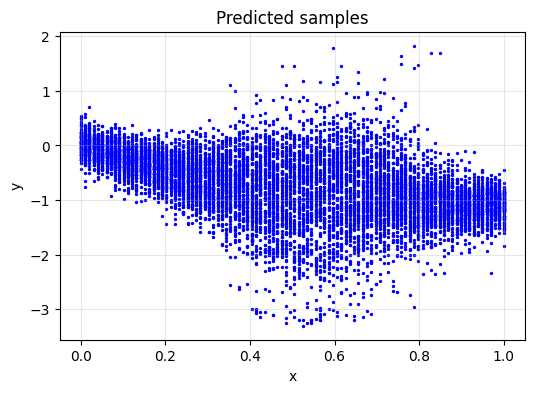

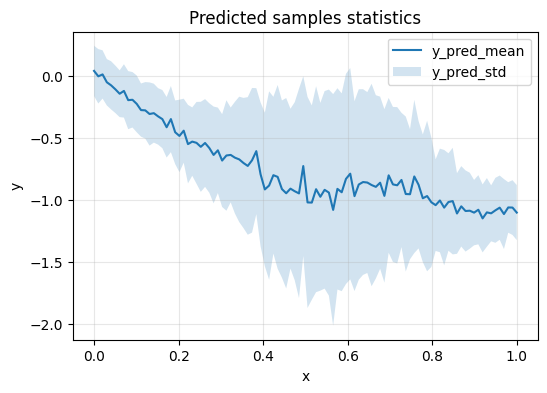

In [199]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted samples')
for i in range(results.shape[0]):
    plt.scatter(locations[i]*torch.ones(num_samples), results[i], s=2, c='b', label='y_t')
# plt.ylim(-2, 5)
# calculate the mean and std of the predicted samples
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted samples statistics')
y_pred_mean = np.mean(results, axis=1)
# get the variance of the predicted samples
y_pred_std = np.std(results, axis=1)
# plot the mean and std of the predicted samples
plt.plot(locations, y_pred_mean, label='y_pred_mean')
plt.fill_between(locations, y_pred_mean - y_pred_std, y_pred_mean + y_pred_std, alpha=0.2, label='y_pred_std')
plt.legend()

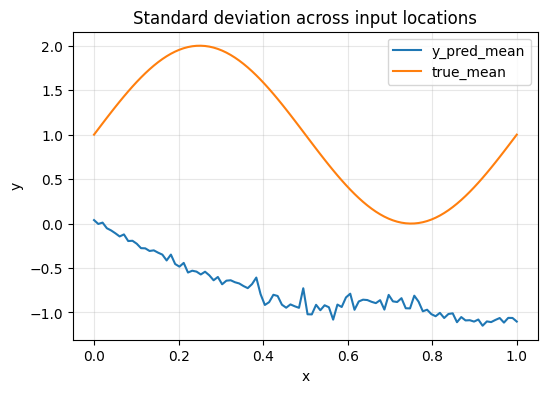

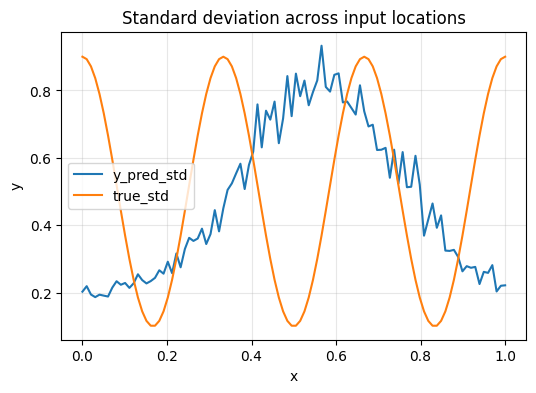

In [198]:
# plot the standard deviation across input locations
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard deviation across input locations')
plt.plot(locations, y_pred_mean, label='y_pred_mean')
# plot the true mean
plt.plot(locations, 1 + np.sin(2 * np.pi * locations), label='true_mean')
plt.legend()

# plot the standard deviation across input locations
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard deviation across input locations')
plt.plot(locations, y_pred_std, label='y_pred_std')
# plot the true standard deviation
plt.plot(locations, 0.5 + 0.4 * np.cos(6 * np.pi * locations), label='true_std')
# plt.ylim(-1, 1.5)
plt.legend()